# Data Processing: An introduction to Pandas

* Including material from *Python for Data Analysis* by Wes McKinney, 2nd ed., O'Reilly, 2017.
* Based also on Chapter 2 of *Learning IPython for Interactive Computing and Data Visualization*, 2nd ed., by Cyrille Rossant, Packt Publishing, 2015.

---

> John Pavlopoulos, Assistant Professor <br />
> Department of Informatics, Athens University of Economics and Business <br />
> ipavlopoulos@aueb.gr <br/><br/>

## Setting the Scene

* We start by importing a few of the packages we'll need.

* Most data analytics in Python is performed using the following packages:

   * [NumPy](https://www.numpy.org/)
   
   * [pandas](https://pandas.pydata.org/)
   
   * [matplotlib](https://matplotlib.org/)
   
   * [seaborn](https://seaborn.pydata.org)
   
   * [scipy](https://www.scipy.org/)
   
* To perform the analysis, we will be using [Jupyter](http://jupyter.org/).

* If you are using the Anaconda distribution, these packages are already included. 

* If you are using standard Python, you can install them with:

   * `pip install numpy`
   * `pip install pandas`
   * `pip install matplotlib`
   * `pip install seaborn`
   * `pip install scipy`
   * `pip install jupyter` 
   
* Note that if you have both version 2 and version 3 of Python installed you may need to use `pip3`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# %matplotlib inline # useful in colab (storing graphs in the notebook)

* The last line is only required for Jupyter notebooks, not for direct Python use.

## Obtaining the Data

* Then we download the data we'll be using.

* Data ragarding yellow taxi fares in NYC is available at https://raw.githubusercontent.com/ipython-books/minibook-2nd-data/master/nyc_taxi.zip.

* After unzipping we get two files, `data/nyc_data.csv` and `data/nyc_fares.csv`.

* We'll be referring to them by two variables.

In [2]:
# !unzip nyc_taxi.zip # then, stored in a folder called 'taxi' 
data_filename = '../../../data/taxi/nyc_data.csv'
fare_filename = '../../../data/taxi/nyc_fare.csv'

* Let's have a look at the form of the data.

```
medallion,hack_license,vendor_id,rate_code,store_and_fwd_flag,pickup_datetime,dropoff_datetime,passenger_count,trip_time_in_secs,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
76942C3205E17D7E7FE5A9F709D16434,25BA06A87905667AA1FE5990E33F0E2E,VTS,1,,2013-01-01 00:00:00,2013-01-01 00:05:00,3,300,0.61,-73.955925,40.781887,-73.963181,40.777832000000004
517C6B330DBB3F055D007B07512628B3,2C19FBEE1A6E05612EFE4C958C14BC7F,VTS,1,,2013-01-01 00:05:00,2013-01-01 00:21:00,1,960,3.28,-74.005501,40.745734999999996,-73.964943,40.755722
ED15611F168E41B33619C83D900FE266,754AEBD7C80DA17BA1D81D89FB6F4D1D,CMT,1,N,2013-01-01 00:05:52,2013-01-01 00:12:18,1,386,1.5,-73.969955,40.79977,-73.954567,40.787392
B33E704CC189E80C9671230C16527BBC,6789C77E1CBDC850C450D72204702976,VTS,1,,2013-01-01 00:06:00,2013-01-01 00:06:00,6,0,0.0,-73.99143199999999,40.755081,-73.991417,40.755085```

## Looking into the data
* The data is in the CSV format (comma separated values).

* A file comprises records, one per row.

* In each row, each field of the record is separated by comma (or some other delimiter) from the next field.

* In this way we can think of rows composed of columns.

* The first row may contain the names of the columnns, in which case it is a header.

* Parsing a CSV file without an appropriate library is complicated because there are rules for escaping commas when they are inside a column, etc.

## Reading the Data

* We'll use the `read_csv()` function provided by Pandas.

In [3]:
data = pd.read_csv(data_filename, 
                   parse_dates=['pickup_datetime','dropoff_datetime'])
    
fare = pd.read_csv(fare_filename, 
                   parse_dates=['pickup_datetime'])

In [4]:
data.sample()

,medallion,hack_license,vendor_id,rate_code,store_and_fwd_flag,pickup_datetime,dropoff_datetime,passenger_count,trip_time_in_secs,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
374152,5C4C79758996A7382BDE4A0D4884EB1B,070AFCC94498161B2ACD32A76F2550C6,VTS,1,NaN,2013-06-05 09:07:00,2013-06-05 09:33:00,1,1560,2.72,-74.003273,40.731533,-73.973206,40.755348


## Dataframes

* The `data` and `fare` variables are `DataFrame` objects. 

* A `DataFrame` is a table containing rows (observations or samples) and columns (features or variables). 

* DataFrames can contain text, numbers, dates, and other types of data. 

* The `head()` method shows the first lines of a DataFrame.

In [12]:
data.head(3)

,medallion,hack_license,vendor_id,rate_code,store_and_fwd_flag,pickup_datetime,dropoff_datetime,passenger_count,trip_time_in_secs,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
0,76942C3205E17D7E7FE5A9F709D16434,25BA06A87905667AA1FE5990E33F0E2E,VTS,1,NaN,2013-01-01 00:00:00,2013-01-01 00:05:00,3,300,0.61,-73.955925,40.781887,-73.963181,40.777832
1,517C6B330DBB3F055D007B07512628B3,2C19FBEE1A6E05612EFE4C958C14BC7F,VTS,1,NaN,2013-01-01 00:05:00,2013-01-01 00:21:00,1,960,3.28,-74.005501,40.745735,-73.964943,40.755722
2,ED15611F168E41B33619C83D900FE266,754AEBD7C80DA17BA1D81D89FB6F4D1D,CMT,1,N,2013-01-01 00:05:52,2013-01-01 00:12:18,1,386,1.50,-73.969955,40.799770,-73.954567,40.787392


* Similarly, the `tail()` method shows the last lines of a DataFrame.

In [13]:
data.tail(3)

,medallion,hack_license,vendor_id,rate_code,store_and_fwd_flag,pickup_datetime,dropoff_datetime,passenger_count,trip_time_in_secs,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
846942,D87EB3AD2ED303B3D92E37D871B2C2E9,F578F0435B49B3D7B9A7AAFC663A82CD,VTS,1,NaN,2013-12-31 23:59:00,2014-01-01 00:05:00,1,360,2.23,-73.993492,40.729347,-74.013725,40.702332
846943,F74743D90F84644B1FA4576F4A82A8A3,537121DB04EC62BADFA44D8F03755A64,VTS,1,NaN,2013-12-31 23:59:00,2014-01-01 00:08:00,1,540,1.76,-73.978477,40.772945,-73.963814,40.773922
846944,E5DCEBA68A6094576B10AFC609C61E29,735F78FA4CB06B5CB7122FF31822F68E,CMT,1,N,2013-12-31 23:59:24,2014-01-01 00:22:26,1,1381,4.50,-73.987206,40.750568,-73.970909,40.795815


* The `describe()` method shows descriptive statistics per column, as shown below.

In [14]:
data.describe()

,rate_code,passenger_count,trip_time_in_secs,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
count,846945.000000,846945.000000,8.469450e+05,8.469450e+05,846945.000000,846945.000000,846945.000000,846945.000000
mean,1.026123,1.710272,8.125239e+02,9.958211e+00,-73.975155,40.750490,-73.974197,40.750967
std,0.223480,1.375266,1.609831e+04,6.525205e+03,0.035142,0.027224,0.033453,0.030766
min,0.000000,0.000000,-1.000000e+01,0.000000e+00,-74.098305,40.009911,-74.099998,40.009911
25%,1.000000,1.000000,3.610000e+02,1.050000e+00,-73.992371,40.736031,-73.991570,40.735207
50%,1.000000,1.000000,6.000000e+02,1.800000e+00,-73.982094,40.752975,-73.980614,40.753597
75%,1.000000,2.000000,9.600000e+02,3.200000e+00,-73.968048,40.767460,-73.965157,40.768227
max,6.000000,6.000000,4.294796e+06,6.005123e+06,-73.028473,40.996132,-73.027061,40.998592


## Making Plots with matplotlib

* Visualizing *raw* data, as opposed to aggregated statistics, often allows us to get a general idea about a data set. 

* Here, we will display the pickup and dropoff locations of all trips.

* The first step is to get the actual coordinates from the DataFrame. 

* Let's start by checking the columns of the data.

In [15]:
data.columns

Index(['medallion', 'hack_license', 'vendor_id', 'rate_code',
       'store_and_fwd_flag', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'trip_time_in_secs', 'trip_distance',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude'],
      dtype='object')

* Seek for documentation to get more info.

- **medallion**: a permit to operate a yellow taxi cab in New York City, it is effectively a (randomly assigned) car ID. See also medallions.
- **hack license**: a license to drive the vehicle, it is effectively a (randomly assigned) driver ID. See also hack license.
- **vender id**: e.g., Verifone Transportation Systems (VTS), or Mobile Knowledge Systems Inc (CMT), implemented as part of the Technology Passenger Enhancements Project.
- **rate_code**: taximeter rate, see NYCT&L description.
- **store_and_fwd_flag**: unknown attribute.
- **pickup datetime**: start time of the trip, mm-dd-yyyy hh24:mm:ss EDT.
- **dropoff datetime**: end time of the trip, mm-dd-yyyy hh24:mm:ss EDT.
- **passenger count**: number of passengers on the trip, default value is one.
- **trip time in secs**: trip time measured by the taximeter in seconds.
- **trip distance**: trip distance measured by the taximeter in miles.
- **pickup_longitude** and **pickup_latitude**: GPS coordinates at the start of the trip.
- **dropoff_longitude** and **dropoff_latitude**: GPS coordinates at the end of the trip.

* Four columns represent latitude and longitude.

* To save typing we'll refer to them by four variables.

In [5]:
p_lng = data.pickup_longitude
p_lat = data.pickup_latitude
d_lng = data.dropoff_longitude
d_lat = data.dropoff_latitude

* With pandas, every column of a `DataFrame` can be obtained with the `mydataframe.the_column_name` syntax. 

* An alternative syntax is `mydataframe['the_column_name']`, so the above is the same as:

```python
p_lng = data['pickup_longitude']
p_lat = data['pickup_latitude']
d_lng = data['dropoff_longitude']
d_lat = data['dropoff_latitude']
```

* The dot notation allows us to use tab for autocompleting column names.

* Here, we created four variables with the coordinates of the pickup and dropoff locations. 

* These variables are all `Series` objects.

* We can check some of the longitudes.

In [6]:
 p_lng[:10]

0   -73.955925
1   -74.005501
2   -73.969955
3   -73.991432
4   -73.966225
5   -73.955238
6   -73.985580
7   -73.999413
8   -73.992180
9   -74.006554
Name: pickup_longitude, dtype: float64

* A `Series` is an indexed list of values. 

* Therefore, a `DataFrame` is simply a collection of `Series` columns.

* Before we can make a plot, we need to get the coordinates of points in pixels instead of geographical coordinates. 

* We can use the following function that performs a Mercator projection.

In [7]:
 def lat_lng_to_pixels(lat, lng):
    lat_rad = lat * np.pi / 180.0
    lat_rad = np.log(np.tan((lat_rad + np.pi / 2.0) / 2.0))
    x = 100 * (lng + 180.0) / 360.0
    y = 100 * (lat_rad - np.pi) / (2.0 * np.pi)
    return (x, y)

* NumPy implements many mathematical functions like `np.log()` and `np.tan()`. 

* These functions work on scalar numbers and also on pandas objects such as `Series`. 

* The following function call returns two new `Series` px and py.

In [8]:
px, py = lat_lng_to_pixels(p_lat, p_lng)
px.head(10)

0    29.456688
1    29.442916
2    29.452790
3    29.446824
4    29.453826
5    29.456878
6    29.448450
7    29.444608
8    29.446617
9    29.442624
Name: pickup_longitude, dtype: float64

* The matplotlib `scatter()` function takes two arrays with x and y coordinates as inputs. 

* A scatter plot is a common 2D  figure showing points with various positions, sizes, colors, and marker shapes. 

* The following command displays all pickup locations.

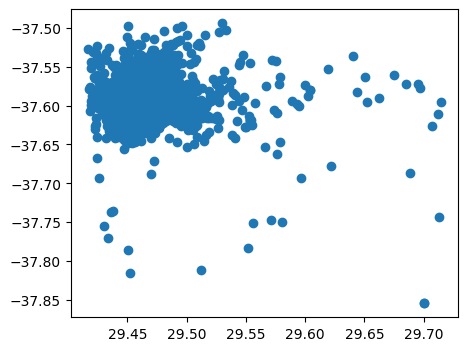

In [9]:
plt.figure(figsize=(5, 4)) # limiting the figure's size
plt.scatter(px, py);

* That's fine, but there are a number of problems.

* First, the markers are too big. 

* Second, there are too many points; we could make them a bit transparent to have a better idea of the distribution of the points. 

* Third, we may want to zoom a bit more around Manhattan. 

* Fourth, the figure could be made bigger.

* And finally, we don't necessarily need the axes here.

* Fortunately matplotlib is highly customizable.

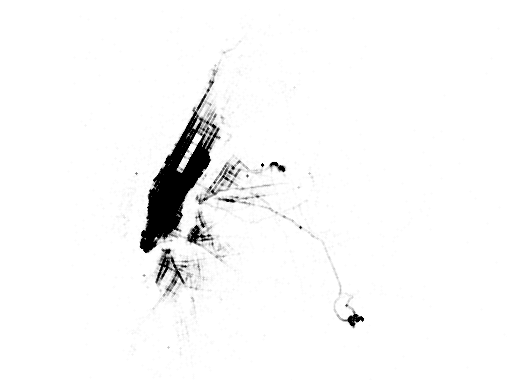

In [10]:
plt.axis('equal')
plt.xlim(29.40, 29.55)
plt.ylim(-37.63, -37.54)
plt.axis('off')
plt.gca().set_facecolor('white')
plt.scatter(px, py, s=.1, alpha=.03, color='black');

* The `figure()` function lets us specify the figure size (in inches).

* The `scatter()` function accepts many keyword arguments to customize
the aspect of the scatter plot. Here:

   * We use a small marker size with the `s` keyword argument.

   * We use a small `alpha` opacity value: the points become nearly transparent, which emphasizes the regions with high density.
   
   * We use an equal aspect ratio with `axis('equal')`.
   
   * We zoom in by specifying the limits of the x and y axes with `xlim()` and `ylim()`.
   
   * We remove the axes with `axes('off')`.
   
   * We specify a white background with `set_axis_bgcolor('white')`; this is required to put a white background on the slide.

## Descriptive statistics with pandas

* Common statistical quantities are one function call away in pandas. 

In [22]:
px.count(), px.min(), px.max()

(846945, 29.417137499999995, 29.714313055555557)

The same, but human-readable:

In [23]:
print(f'count: {px.count()/1000:.0f}K, min: {px.min():.2f}, max: {px.max():.2f}')

count: 847K, min: 29.42, max: 29.71


In [24]:
print(f'avg: {px.mean():.2f},  median: {px.median():.2f}, std: {px.std():.2f}, sem: {px.sem():.2f}')

avg: 29.45,  median: 29.45, std: 0.01, sem: 0.00


* It is straightforward to find the `most common` trip distance:

In [25]:
data['trip_distance'].mode()

0    1.0
Name: trip_distance, dtype: float64

* Or, indeed, the top-10 most common trip distances:

In [26]:
data['trip_distance'].value_counts().iloc[:10]

1.0    21815
0.9    18915
0.8    18449
1.1    18263
1.2    17823
0.7    17155
1.3    16779
1.4    16021
1.5    15070
0.6    14769
Name: trip_distance, dtype: int64

* Now let us visualize the trip distances.

* matplotlib is the main plotting package in Python. 

* Although highly powerful and  exible, it sometimes requires a significant amount of manual tuning in order to generate clean, high-quality, publication-ready figures. 

* Luckily, there are some ready-made styles that we can use.

In [11]:
plt.style.use('ggplot')

* We'll display a histogram of the trip distances. 

* pandas provides a few simple plotting methods for `DataFrame` and `Series` objects. 

* These methods are based on matplotlib. 

* The `hist()` method displays a histogram of the values of a `Series` object. We can specify the histogram bins with the `bins` keyword argument. 

* Here, we use NumPy's `linspace()` function to generate 100 linearly-spaced bins between 0 and 10.


In [12]:
np.linspace(0., 10., 100)

array([ 0.        ,  0.1010101 ,  0.2020202 ,  0.3030303 ,  0.4040404 ,
        0.50505051,  0.60606061,  0.70707071,  0.80808081,  0.90909091,
        1.01010101,  1.11111111,  1.21212121,  1.31313131,  1.41414141,
        1.51515152,  1.61616162,  1.71717172,  1.81818182,  1.91919192,
        2.02020202,  2.12121212,  2.22222222,  2.32323232,  2.42424242,
        2.52525253,  2.62626263,  2.72727273,  2.82828283,  2.92929293,
        3.03030303,  3.13131313,  3.23232323,  3.33333333,  3.43434343,
        3.53535354,  3.63636364,  3.73737374,  3.83838384,  3.93939394,
        4.04040404,  4.14141414,  4.24242424,  4.34343434,  4.44444444,
        4.54545455,  4.64646465,  4.74747475,  4.84848485,  4.94949495,
        5.05050505,  5.15151515,  5.25252525,  5.35353535,  5.45454545,
        5.55555556,  5.65656566,  5.75757576,  5.85858586,  5.95959596,
        6.06060606,  6.16161616,  6.26262626,  6.36363636,  6.46464646,
        6.56565657,  6.66666667,  6.76767677,  6.86868687,  6.96

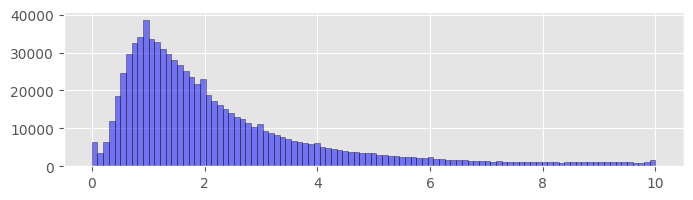

In [16]:
bins = np.linspace(0., 10., 100)
data.trip_distance.hist(bins=bins, color='blue', edgecolor='black', alpha=0.5, figsize=(8, 2));

* We can observe some peaks in the histogram.

* See if you can locate them
> hint: use `value_counts` and `scipy.signal.find_peaks`.

## Selecting data

* Our data set contains almost one million rows. 

* Some analyses can be done by using the whole data set. 

* Other interesting analyses can be made by looking at carefully-chosen subsets of the data. 

* For example, what can we say about the taxi rides done on a particular day, a particular month, or a particular day of week? 

* What about those starting or ending at a particular location? 

* A significant part of real-world data analysis involves such fine-grained selections.

## Selecting Columns

In [30]:
data[['trip_distance', 'trip_time_in_secs']].head(3)

,trip_distance,trip_time_in_secs
0,0.61,300
1,3.28,960
2,1.50,386


* In Python, the square brackets `[]` are used for selecting elements in a list. 

* The same notation is used by pandas to select columns. 

* We need two pairs of brackets because pandas expects a list of columns to select, here `['trip_distance', 'trip_time_ in_secs']`. 

* The end-result is a new `DataFrame` containing just two columns instead of 14.

## Selecting Rows

* Rows of a `DataFrame` are indexed.

* Every row comes with a unique label (or index). 

* Often, this label is just an integer between 0 and `n_rows-1`. 

* In some situations, this label can be something else, like a string. 

* If we had a `DataFrame` giving information about each taxi, the label could be the taxi's medallion (a unique identifer for NYC's taxicabs), or an anonymized version of it.

* The loc attribute of a `DataFrame` is used to select row(s) from their labels. Here, we select the first row.

In [31]:
data.loc[0]

medallion             76942C3205E17D7E7FE5A9F709D16434
hack_license          25BA06A87905667AA1FE5990E33F0E2E
vendor_id                                          VTS
rate_code                                            1
store_and_fwd_flag                                 NaN
pickup_datetime                    2013-01-01 00:00:00
dropoff_datetime                   2013-01-01 00:05:00
passenger_count                                      3
trip_time_in_secs                                  300
trip_distance                                     0.61
pickup_longitude                            -73.955925
pickup_latitude                              40.781887
dropoff_longitude                           -73.963181
dropoff_latitude                             40.777832
Name: 0, dtype: object

* Multiple rows can be selected by providing a list of labels.

In [32]:
data.loc[[0, 100000]]

,medallion,hack_license,vendor_id,rate_code,store_and_fwd_flag,pickup_datetime,dropoff_datetime,passenger_count,trip_time_in_secs,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
0,76942C3205E17D7E7FE5A9F709D16434,25BA06A87905667AA1FE5990E33F0E2E,VTS,1,NaN,2013-01-01 00:00:00,2013-01-01 00:05:00,3,300,0.61,-73.955925,40.781887,-73.963181,40.777832
100000,7461F7106D33D3A5775F4245724606FD,BACEA353BB4106A005BB7836BDCAC0C3,VTS,1,NaN,2013-02-12 18:10:00,2013-02-12 18:20:00,2,600,2.02,-73.966454,40.770512,-73.958862,40.778042


## Selecting rows & columns
* We can also select regularly spaced rows using slices. 

* For example, here is how to select one row out of 10 between rows 1000 and 1100 (inclusive).

* At the same time, we select only the `trip_distance` and the `trip_time_in_secs` columns.

* Note that when slicing with `.loc` in this way, the right end is *included* in the result, in contrast to standard Python practice.


In [17]:
data.loc[1000:1100:10, ['trip_distance', 'trip_time_in_secs']]

,trip_distance,trip_time_in_secs
1000,1.00,441
1010,3.80,691
1020,0.00,7
1030,4.20,902
1040,3.40,1278
1050,1.00,242
1060,1.48,300
1070,3.03,600
1080,0.60,135
1090,2.80,780


### Notes
* Note how we combined column and row selection. 

* Two expressions can be passed to `loc`: the row selection first, and the column selection second (the two expressions are separated by a comma).

* `loc` expects actual labels and, unlike normal Python slices, the start and end points are both inclusive.

* We could have used `iloc` instead of `loc` to specify index positions rather than labels.

## Filtering with Boolean Indexing

* Instead of selecting rows by labels, we can also select rows satisfying specific properties. 

* This is a more common use-case in data analysis.

* For example, let's select the longest rides.

* `data.trip_distance>50` is a `Series` object containing boolean values for all rows, depending on whether the trip distance is higher or lower than 50. 

In [24]:
(data.trip_distance>50).sample(10)

739768    False
264780    False
287057    False
764779    False
569483    False
627511    False
58083     False
474136    False
846078    False
433709    False
Name: trip_distance, dtype: bool

* The `loc` attribute also works with booleans instead of explicit labels: it will return all rows represented by a `True` boolean value.

* This is the basis of filtering data with pandas.

In [35]:
data.loc[data.trip_distance>50].sample(5)

,medallion,hack_license,vendor_id,rate_code,store_and_fwd_flag,pickup_datetime,dropoff_datetime,passenger_count,trip_time_in_secs,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
134839,FA189EABBB4058AC0359AA1CF30F5313,C707B5A8C6AEF269564272AF66B37564,CMT,1,Y,2013-02-26 17:54:11,2013-02-26 18:45:03,1,3052,69.8,-73.989853,40.729340,-73.964035,40.771950
558665,5A5C516A820FE476E9D3E14101B669AC,C24585AA866FC76A4E09A05F55DC7E54,CMT,2,N,2013-08-29 10:01:40,2013-08-29 11:52:20,1,6640,164.4,-73.791534,40.661026,-73.983734,40.765778
238505,4ADDFBA1E3FD055AB4854D003976F263,2B09130C92CF5199315044DFE89D6356,CMT,1,N,2013-04-09 15:10:48,2013-04-09 15:19:54,1,545,85.3,-73.979851,40.764091,-73.982155,40.777206
450941,849397BEC809E0CBF9FF645FE7FD96A8,BC7E6894AF102A345E3D050121FAA1F2,CMT,1,N,2013-07-09 13:51:02,2013-07-09 14:13:53,4,1371,88.0,-73.987518,40.747070,-73.870758,40.772087
201876,DBCD64B365502F85569B4A264B798AAE,D404427B22B187FE0460668FDEC9937E,CMT,1,N,2013-03-25 09:30:28,2013-03-25 10:07:32,2,2224,61.0,-73.988136,40.749702,-73.887688,40.859402


## More complicated filtering
* We might want to choose the distance threshold depending on certain conditions. 

* For example, we might want to keep the 1% longest trips.


In [45]:
data.loc[data.trip_distance >= data.trip_distance.quantile(0.99)].sample(5)

,medallion,hack_license,vendor_id,rate_code,store_and_fwd_flag,pickup_datetime,dropoff_datetime,passenger_count,trip_time_in_secs,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
407143,95EED289585F63FF3E6D1F81EE2BD137,208A3FD264C387FAFD3CDA86C8E16B53,CMT,2,N,2013-06-19 07:59:09,2013-06-19 08:44:46,1,2736,18.20,-73.987785,40.758835,-73.776413,40.645180
378719,9F98EBCCE457E488A11CB506F7BE885D,6FEC7306C7BD6C3E7B61F127B3E39312,VTS,2,NaN,2013-06-07 01:17:00,2013-06-07 01:45:00,1,1680,18.43,-73.782074,40.644749,-73.979645,40.729141
759899,9473B2600EF2EFC9E9B89842CBAFC4AB,28DD279F812894E72D9B8D66F8A47244,VTS,1,NaN,2013-11-22 14:08:00,2013-11-22 14:43:00,1,2100,18.11,-73.791519,40.645851,-73.961288,40.713009
522526,28B5DBE8F4DC2237B8C91385F59B698B,BBFAF97FF9290D14D3D862F55202B90E,CMT,2,N,2013-08-12 14:25:55,2013-08-12 15:39:18,2,4403,18.00,-74.007759,40.741093,-73.816505,40.703178
817321,E787F1A56FE4D512C65454A82CAB9CB9,D5E1EFC554B010E89D2E309C65FEA252,VTS,2,NaN,2013-12-17 14:03:00,2013-12-17 15:04:00,1,3660,18.85,-73.988564,40.722511,-73.789436,40.647125


## Handling Missing Data

* Real-world data sets are rarely perfect, and having missing values in a data set is the rule rather than the exception.

* In pandas, missing data is represented by `NaN` (Not a Number) or `None`. pandas provides several `Series` and `DataFrame` methods to deal with missing data:

   * `isnull()`, `isna()` indicates whether values `NaN` or `None`.

   * `notnull()` `notna()` indicates the opposite.
   
   * `dropna()` removes missing data.

   * `fillna(some_default_value)` replaces missing data with a default value.

## Computing with vector operations

* The `trip_time_in_secs column` contains the trip durations in seconds. How can we convert these values to minutes? 

* More generally, how can we make computations on DataFrames?

* A first approach would be to use a for loop, iterating over all rows and making numerical computations successively inside that loop. This is not the best way to do it.

* Whereas Python loops are possible in this situation, they would be extremely slow. For this reason, they should be avoided as much as possible. 

* pandas allows you to perform vector operations on `DataFrame` and `Series` objects. These operations are quite natural, because they follow standard mathematical notations. For example, let's add a new column containing the trip durations in minutes.

In [46]:
data['trip_time_in_mins'] = data.trip_time_in_secs / 60.0
data[['trip_time_in_secs', 'trip_time_in_mins']].head(3)

,trip_time_in_secs,trip_time_in_mins
0,300,5.000000
1,960,16.000000
2,386,6.433333


## Notes
* The `data.trip_time_in_secs` notation represents a `Series` object. 

* The `/` symbol represents floating-point division in Python 3. 

* It normally works with numbers only. However, pandas extends this operator to work with Series and DataFrames as well, in which case it automatically operates on all elements. 

* Here, all elements of `data.trip_time_in_secs` are divided by 60.

## More Notes
* The same notation would also work if we had another `Series` object of the same size in the second term. 

* In that case, the division would occur on an element-wise basis.

* The first item in the Series on the left would be divided by the first in the right, the second by the second, and so on.

* A `Series` object is a vector with indices (or labels). The indices determine which values are used when operating Series objects together.

## Aligned operations

In [47]:
a = data.trip_distance[:5]
a

0    0.61
1    3.28
2    1.50
3    0.00
4    1.31
Name: trip_distance, dtype: float64

In [48]:
b = data.trip_distance[2:6]
b

2    1.50
3    0.00
4    1.31
5    5.81
Name: trip_distance, dtype: float64

* These two `Series` objects have different but overlapping sets of indices. 

* Although they don't have the same size, we can add them together.

In [49]:
 a + b

0     NaN
1     NaN
2    3.00
3    0.00
4    2.62
5     NaN
Name: trip_distance, dtype: float64

* The result is a new `Series` object containing the *aligned* sum of `a` and `b`. 

* The set of indices of `a + b` is the union of the indices of `a` and `b`. 

* When one value is missing, we get an operation with an undefined value, which is `NaN` (Not a Number). 

* When the indices overlap, the sum is correctly computed. This feature, *alignment*, makes it quite convenient to operate on labeled data.

* Other mathematical operations (`+`, `*`, etc.) work similarly. 

* Furthermore, NumPy implements many mathematical functions like `np.log()` and `np.sin()`.

* They not only work on scalar numbers but also on Series and DataFrames. 

* This is called *vectorization*, because this concept relates to mathematical operations performed on vectors. 

## Deleting and Popping

* If we want to delete a column, we can use `del()`.

In [50]:
df = pd.DataFrame([('falcon', 'Falconidae', 'Aves', 389.0),
                   ('parrot', 'Psittacopasserae', 'Aves', 24.0),
                   ('lion', 'Felidae', 'Mammalia', 80.5),
                   ('chimpanzee','Hominidae', 'Mammalia', np.nan)],
                  columns=('name', 'family', 'class', 'max_speed'))
df

,name,family,class,max_speed
0,falcon,Falconidae,Aves,389.0
1,parrot,Psittacopasserae,Aves,24.0
2,lion,Felidae,Mammalia,80.5
3,chimpanzee,Hominidae,Mammalia,NaN


In [51]:
del df['class']
df

,name,family,max_speed
0,falcon,Falconidae,389.0
1,parrot,Psittacopasserae,24.0
2,lion,Felidae,80.5
3,chimpanzee,Hominidae,NaN


* If we want to delete & return a column (`Series`) we can use `pop()`:

In [52]:
family = df.pop('family')
family

0          Falconidae
1    Psittacopasserae
2             Felidae
3           Hominidae
Name: family, dtype: object

In [53]:
df

,name,max_speed
0,falcon,389.0
1,parrot,24.0
2,lion,80.5
3,chimpanzee,NaN


## Working with Text

* Efficient vectorized operations can also be done on text. Let's have a look at `data.medallion`.

In [54]:
data.medallion.head(3)

0    76942C3205E17D7E7FE5A9F709D16434
1    517C6B330DBB3F055D007B07512628B3
2    ED15611F168E41B33619C83D900FE266
Name: medallion, dtype: object

* This column contains anonymized versions of the taxis' medallions. 

* The `str` attribute gives us access to many vectorized string processing functions.

* Here, for example, we extract the first four characters of every medallion.

In [55]:
data.medallion.str.slice(0, 4).head(3)

0    7694
1    517C
2    ED15
Name: medallion, dtype: object

## Regular Expressions
* There are many more methods for manipulating strings (text).

* For example, we can find strings that match a particular *regular expression* (RE).

* Here is how we can find the rows with medallions that start with two digits.
* **In RE terms**: find medallions that start (`^`) with digit (`\d`), two of them (`{2}`), and then anything can follow (`.`) for any number of times (`*`).

In [56]:
data.medallion.str.findall(r'^\d{2}.*').head(10)

0    [76942C3205E17D7E7FE5A9F709D16434]
1    [517C6B330DBB3F055D007B07512628B3]
2                                    []
3                                    []
4                                    []
5    [61E558C4FCB0BCB8562FC37B06B97FFE]
6    [36EDC01D57A6489E2DEE50734ECB327D]
7    [131162C7685521FA81608D3C42E4EF29]
8    [22467390B5CCC51FD1B12659F6084B2F]
9    [939D5E5E9555C02F0DB5B4B4F2D6BCBC]
Name: medallion, dtype: object

* If we want to actually filter these rows, then we use `str.contains()`, which returns a `Series` of `True` and `False` values:

In [57]:
data.medallion.str.contains(r'^\d{2}.*').head(10)

0     True
1     True
2    False
3    False
4    False
5     True
6     True
7     True
8     True
9     True
Name: medallion, dtype: bool

* Then we can access `data` based on the results of `str.contains()`.

In [58]:
data[data.medallion.str.contains(r'^\d{2}.*')].head(3)

,medallion,hack_license,vendor_id,rate_code,store_and_fwd_flag,pickup_datetime,dropoff_datetime,passenger_count,trip_time_in_secs,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_time_in_mins
0,76942C3205E17D7E7FE5A9F709D16434,25BA06A87905667AA1FE5990E33F0E2E,VTS,1,NaN,2013-01-01 00:00:00,2013-01-01 00:05:00,3,300,0.61,-73.955925,40.781887,-73.963181,40.777832,5.0
1,517C6B330DBB3F055D007B07512628B3,2C19FBEE1A6E05612EFE4C958C14BC7F,VTS,1,NaN,2013-01-01 00:05:00,2013-01-01 00:21:00,1,960,3.28,-74.005501,40.745735,-73.964943,40.755722,16.0
5,61E558C4FCB0BCB8562FC37B06B97FFE,76DC5E351A0E646679BCA84B18B37B9A,VTS,1,NaN,2013-01-01 00:07:00,2013-01-01 00:34:00,1,1620,5.81,-73.955238,40.768978,-73.994064,40.720299,27.0


# Working with Dates and Times

* pandas provides many methods to operate on dates and times. Common operations include:

     * getting the day, day of week, hour, or any other quantity from dates
     
     * selecting ranges of dates
     
     * computing time ranges
     
     * dealing with different time zones

## Day & Time Components
* The date and time operations work with objects of type `datetime64`.

* This is the kind of object we get when we use the `parse_dates` keyword argument in the `pd.read_csv()` method.

* The `dt` attribute of `datetime64` objects gives us access to day and time components. 

* Here is how to get the day of the week of the taxi trips (Monday = 0, Sunday = 6).

In [59]:
data.pickup_datetime.dt.dayofweek[::200000]

0         1
200000    6
400000    5
600000    0
800000    1
Name: pickup_datetime, dtype: int64

* As another example, let's find all night rides that finished the next day.

In [60]:
day_p = data.pickup_datetime.dt.day 
day_d = data.dropoff_datetime.dt.day 
selection = (day_p > day_d) 
print(len(data.loc[selection]))
data.loc[selection].head(3)

260


,medallion,hack_license,vendor_id,rate_code,store_and_fwd_flag,pickup_datetime,dropoff_datetime,passenger_count,trip_time_in_secs,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_time_in_mins
72271,B0053FF54D4CD3D52C1F1C3730B32127,53C4C55016FE8671A2CE155A13AA4212,CMT,1,N,2013-01-31 23:30:28,2013-02-01 00:03:44,1,1995,10.00,-73.988007,40.728210,-73.956825,40.625660,33.250000
72274,F2751CE89ED7E006D8E9C243FC31D01C,0747F87EFE3D6B5697F97607A6352962,VTS,1,NaN,2013-01-31 23:32:00,2013-02-01 00:01:00,1,1740,12.63,-73.968605,40.799252,-73.862328,40.876064,29.000000
72306,66B87B60B19890A4C2E0CB1566256324,F8DABF9035728F406AF5321D8547A438,CMT,1,N,2013-01-31 23:46:25,2013-02-01 00:03:57,1,1051,4.50,-73.987740,40.732430,-73.970352,40.784145,17.516667


## Group By 

* A *group by* process involves the following steps:

   * *Splitting* the data into groups based on some criteria.
   
   * *Applying* a function to each group independently.
   
   * *Combining* the results into a data structure.
  

![Group By Illustration](group_aggregation.png)

* The name Group By comes from the SQL `GROUP BY` operation, which works as follows:

```sql
SELECT Column1, Column2, mean(Column3), sum(Column4)
FROM SomeTable
GROUP BY Column1, Column2
```

* Let's examine some data with two data columns of interest and two key columns.

In [61]:
df = pd.DataFrame({'key1': ['a', 'a', 'b', 'b', 'a'],
                   'key2': ['one', 'two', 'one', 'two', 'one'],
                   'data1': np.random.randn(5),
                   'data2': np.random.randn(5)})
df

,key1,key2,data1,data2
0,a,one,0.116489,-0.831524
1,a,two,-0.914449,0.339616
2,b,one,1.619922,0.680681
3,b,two,-0.494810,0.183802
4,a,one,-1.248999,-0.427901


* Let's group by `key1` and check the groups we get.

In [122]:
grouped = df.groupby('key1') # <== grouping by key1

for name, group in grouped:
    print(name)
    print(group)

a
  key1 key2     data1     data2
0    a  one  0.116489 -0.831524
1    a  two -0.914449  0.339616
4    a  one -1.248999 -0.427901
b
  key1 key2     data1     data2
2    b  one  1.619922  0.680681
3    b  two -0.494810  0.183802


* We can now easily, for instance, get the mean for each group.

In [64]:
grouped.mean(numeric_only=True) # working with numeric columns only

,data1,data2
key1,,
a,-0.682320,-0.306603
b,0.562556,0.432241


* Now let's group by both `key1` and `key2` and check the groups we get.

In [123]:
grouped = df.groupby(['key1', 'key2'])

for (k1, k2), group in grouped:
    print(k1, k2)
    print(group)

a one
  key1 key2     data1     data2
0    a  one  0.116489 -0.831524
4    a  one -1.248999 -0.427901
a two
  key1 key2     data1     data2
1    a  two -0.914449  0.339616
b one
  key1 key2     data1     data2
2    b  one  1.619922  0.680681
b two
  key1 key2    data1     data2
3    b  two -0.49481  0.183802


* Let's check the means again

In [125]:
grouped.mean(numeric_only=True)

data1     data2
key1 key2                    
a    one  -0.566255 -0.629712
     two  -0.914449  0.339616
b    one   1.619922  0.680681
     two  -0.494810  0.183802

# Group By and Restaurant Data

* As a more realistic example, let's examine data from restaurant tips.

* The dataset, published by <font color="green">Bryant et al. (1995)</font>, is in a CSV format:

```
total_bill,tip,sex,smoker,day,time,size
16.99,1.01,Female,No,Sun,Dinner,2
10.34,1.66,Male,No,Sun,Dinner,3
21.01,3.5,Male,No,Sun,Dinner,3
```

<font color="green">Bryant, P. G. and Smith, M. A. (1995), Practical Data Analysis: Case Studies in Business Statistics, Richard D. Irwin Publishing, Homewood, IL</font>

In [27]:
import pandas as pd
tips = pd.read_csv('https://raw.githubusercontent.com/pandas-dev/pandas/main/pandas/tests/io/data/csv/tips.csv')
tips.sample(3)

,total_bill,tip,sex,smoker,day,time,size
68,20.23,2.01,Male,No,Sat,Dinner,2
75,10.51,1.25,Male,No,Sat,Dinner,2
77,27.20,4.00,Male,No,Thur,Lunch,4


* Let's add the tip percentage

In [28]:
# Add tip percentage of total bill
tips['tip_pct'] = tips['tip'] / tips['total_bill']
tips.sample(3)

,total_bill,tip,sex,smoker,day,time,size,tip_pct
243,18.78,3.0,Female,No,Thur,Dinner,2,0.159744
97,12.03,1.5,Male,Yes,Fri,Dinner,2,0.124688
71,17.07,3.0,Female,No,Sat,Dinner,3,0.175747


## Group by sex and smoker

In [128]:
grouped = tips.groupby(['sex', 'smoker'])

* And then we can compute the mean and the standard deviation (aggregated with `.agg`) per group.

In [75]:
cols = ['total_bill', 'tip', 'size', 'tip_pct'] # ignoring day and time-columns
grouped[cols].agg(['mean', 'std'])

total_bill                 tip                size            \
                    mean       std      mean       std      mean       std   
sex    smoker                                                                
Female No      18.105185  7.286455  2.773519  1.128425  2.592593  1.073146   
       Yes     17.977879  9.189751  2.931515  1.219916  2.242424  0.613917   
Male   No      19.791237  8.726566  3.113402  1.489559  2.711340  0.989094   
       Yes     22.284500  9.911845  3.051167  1.500120  2.500000  0.892530   

                tip_pct            
                   mean       std  
sex    smoker                      
Female No      0.156921  0.036421  
       Yes     0.182150  0.071595  
Male   No      0.160669  0.041849  
       Yes     0.152771  0.090588

# Men vs Women
## Interlude: The Natsal Study

* While we are at the topic of male vs. female behaviour, let's explore the data of the UK's [National Survey of Sexual Attitudes and Lifestyles](http://www.natsal.ac.uk/home.aspx).

* In particular, we'll explore whether there is a difference in the number of partners of men vs. women aged 35-44.

* We'll get the data from the web site accompanying David Spiegelhalter's *The Art of Statistics*.

In [29]:
natsal = pd.read_csv('https://github.com/dspiegel29/ArtofStatistics/raw/master/02-4-reported-partners/02-4-sexual-partners-counts-x.csv')

* Let's see how the data looks like:

In [30]:
natsal

,NumPartners,MenCount,MenPercent,WomenCount,WomenPercent
0,0,6,0.75,5,0.42
1,1,100,12.56,212,17.77
2,2,44,5.53,93,7.80
3,3,39,4.90,130,10.90
4,4,58,7.29,88,7.38
...,...,...,...,...,...
132,403,1,0.13,0,0.00
133,450,0,0.00,0,0.00
134,500,1,0.13,0,0.00
135,501,1,0.13,0,0.00


* We would like to visualize the behavior of men vs. women.

* To do this, we'll create another `DataFrame` in the so-called *long-format*, where we will have rows for men and women.

* We start by getting the men.

In [31]:
men = natsal.loc[:, ['NumPartners', 'MenCount', 'MenPercent']]
men['Male'] = True
men.rename(columns={'MenCount' : 'Count', 'MenPercent': 'Percent'}, inplace=True)
men.sample(3)

,NumPartners,Count,Percent,Male
87,92,0,0.00,True
112,153,1,0.13,True
131,401,0,0.00,True


* Then we get the women.

In [32]:
women = natsal.loc[:, ['NumPartners', 'WomenCount', 'WomenPercent']]
women['Male'] = False
women.rename(columns={'WomenCount' : 'Count', 'WomenPercent': 'Percent'}, inplace=True)
women.sample(3)

,NumPartners,Count,Percent,Male
83,88,0,0.00,False
25,25,16,1.34,False
109,150,0,0.00,False


* We combine the two with `.concat`.

In [35]:
natsal_long = pd.concat([men, women])
natsal_long.sample(3)

,NumPartners,Count,Percent,Male
51,51,0,0.00,True
49,49,0,0.00,True
0,0,6,0.75,True


* We will plot the data as a barplot, using seaborn.

* We will restrict our attention to no more than 50 partners, otherwise the data will appear cluttered, and perhaps anything above that is an outlier.

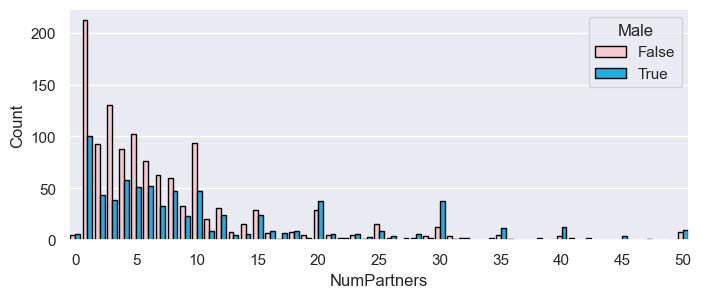

In [41]:
sns.set(style="darkgrid")
plt.figure(figsize=(8, 3))
natsal_long_50 = natsal_long[natsal_long.NumPartners <= 50]
ax = sns.barplot(x="NumPartners", 
                 y="Count", 
                 hue="Male", 
                 palette={True: 'deepskyblue', False: 'pink'}, 
                 edgecolor='black', 
                 data=natsal_long_50)
ax.set_xticks(range(0, 50+1, 5))
_ = ax.set_xticklabels(range(0, 51, 5))

* Do you see the peaks on round numbers?

# Group By on Taxis Data

* Let's return to the taxi rides data set.

* We want to explore the pattern of weekly rides.

In [89]:
weekly = data.groupby(data.pickup_datetime.dt.isocalendar().week)
len(weekly)

52

* The `groupby` method returned an object with one group for each week of the year.

* The `size()` method returns the number of rows in each group.

In [90]:
y = weekly.size()
y.head(3)

week
1    17042
2    15941
3    17017
dtype: int64

## Plot taxi rides (#) per week
* We'll plot the number of taxi rides per week.

* The `y` variable already contains that number, which we'll put into the y axis.

* In the `x` axis we'll put the first day that we have a ride in each week.

In [91]:
x = weekly.pickup_datetime.first()
x[:3]

week
1   2013-01-01 00:00:00
2   2013-01-07 00:03:00
3   2013-01-14 00:00:51
Name: pickup_datetime, dtype: datetime64[ns]

* Now we can create our plot, using the 1st day with ride per week (horizontally), the rides number (vertically).

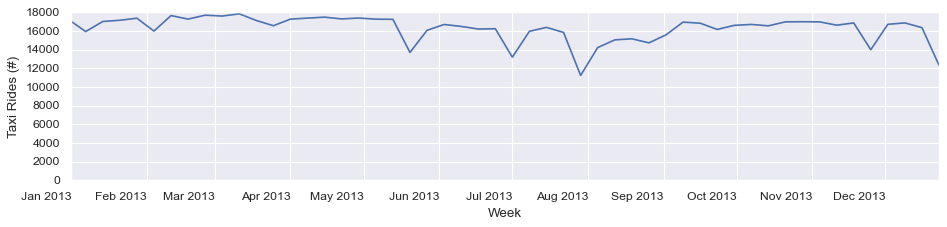

In [200]:
pd.Series(y.values, index=x).plot(figsize=(14, 3), rot=0) # wide fig, so labels don't need to rotate 
plt.ylim(0) # the lower vertical value is 0
plt.xlabel('Week'); plt.ylabel('Taxi Rides (#)'); # stacking axis labeling in one line

## Visualizing Taxi Activity

* Another thing we can do is to visualize the daily activity of a taxi.

* To do that, we need to download the *full* dataset. 

* The dataset is available at http://www.andresmh.com/nyctaxitrips/.

* We need only the [taxi trips](https://archive.org/download/nycTaxiTripData2013/trip_data.7z).

* This is a big file; 3.82Gb, so we have to think about how we can handle it efficiently.

* Since we will be dealing with individual taxis, we need to find out which taxis we will be dealing with.

* The following Linux command will extract all the unique medallions and save them to the file `medallions.txt`.

```bash
7za e -so trip_data.7z | cut -f1 -d, | sort -u > medallions.txt
```

* Then the following Linux command will extract all the trips of a chosen taxi:

```bash
7za e -so trip_data.7z | grep 8853EBAA8F2483A858AAB903B4C5DBF5 > taxi_trips.csv
```

* In the above, `8853EBAA8F2483A858AAB903B4C5DBF5` is the medallion we have picked.

In [111]:
!7za e -so data/trip_data.7z | grep 8853EBAA8F2483A858AAB903B4C5DBF5 > data/taxi_trips.csv

* We can now handle it easily in pandas. 

In [201]:
taxi_trips = pd.read_csv('data/taxi_trips.csv', 
                         header=None,
                         parse_dates=[5, 6])
print(taxi_trips.shape)
taxi_trips.sample(3)

(16922, 14)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
5264,8853EBAA8F2483A858AAB903B4C5DBF5,1C1A9EC8F2C77EA72394132A6FAF2DCC,VTS,1,NaN,2013-12-24 21:16:00,2013-12-24 21:40:00,6,1440,6.43,-73.993073,40.758423,-73.940186,40.709812
9270,8853EBAA8F2483A858AAB903B4C5DBF5,34C228892CBB551F7CD9BA0A43F1C233,VTS,1,NaN,2013-04-19 15:22:00,2013-04-19 15:42:00,1,1200,3.18,-73.955811,40.781914,-73.935806,40.818596
8523,8853EBAA8F2483A858AAB903B4C5DBF5,C5C387AD27C255587105FDDC437D7F09,VTS,1,NaN,2013-03-14 07:57:00,2013-03-14 08:15:00,1,1080,2.76,-73.962852,40.755680,-73.953918,40.784431


* We also need the first line of the file, to add the columns.

In [185]:
!7za e -so data/trip_data.7z | head -n 1

medallion,hack_license,vendor_id,rate_code,store_and_fwd_flag,pickup_datetime,dropoff_datetime,passenger_count,trip_time_in_secs,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude


In [202]:
columns = 'medallion,hack_license,vendor_id,rate_code,store_and_fwd_flag,pickup_datetime,dropoff_datetime,passenger_count,trip_time_in_secs,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude'.split(',')
taxi_trips.columns = columns
taxi_trips.sample(2)

,medallion,hack_license,vendor_id,rate_code,store_and_fwd_flag,pickup_datetime,dropoff_datetime,passenger_count,trip_time_in_secs,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
15038,8853EBAA8F2483A858AAB903B4C5DBF5,CA4AF8FD778953A7746CED994251ED96,VTS,1,NaN,2013-08-29 13:51:00,2013-08-29 14:01:00,2,600,0.88,-73.990204,40.746567,-73.999382,40.738808
10536,8853EBAA8F2483A858AAB903B4C5DBF5,D26588CA7D48ED240280357141435709,VTS,1,NaN,2013-05-22 22:55:00,2013-05-22 23:16:00,1,1260,4.23,-73.958008,40.768890,-74.005768,40.740131


* We'll get a subset of the original dataframe with only the two columns that we need.

In [156]:
taxi_trips_routes = taxi_trips[['pickup_datetime', 'dropoff_datetime']]
taxi_trips_routes.head()

,pickup_datetime,dropoff_datetime
0,2013-01-13 07:04:00,2013-01-13 07:17:00
1,2013-01-13 06:40:00,2013-01-13 06:43:00
2,2013-01-13 06:45:00,2013-01-13 06:48:00
3,2013-01-13 07:45:00,2013-01-13 07:48:00
4,2013-01-13 10:45:00,2013-01-13 11:02:00


* Now we will write a helper function that takes a `datetime` object and converts it to the number of minutes elapsed since midnight.

In [205]:
def convert_to_mins(t):
    midnight = t.replace(hour=0, minute=0, second=0, microsecond=0)
    mins = (t - midnight).total_seconds() // 60
    return mins

* We will use the helper function to create two new columns with the equivalent in minutes elapsed since midnight for the two timestamps.

In [206]:
taxi_trips_routes['pickup_mins'] = taxi_trips_routes['pickup_datetime'].apply(convert_to_mins).apply(int)
taxi_trips_routes['dropoff_mins'] = taxi_trips_routes['dropoff_datetime'].apply(convert_to_mins).apply(int)
taxi_trips_routes.head()

,pickup_datetime,dropoff_datetime,pickup_mins,dropoff_mins,minutes
0,2013-01-13 07:04:00,2013-01-13 07:17:00,424,437,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,2013-01-13 06:40:00,2013-01-13 06:43:00,400,403,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,2013-01-13 06:45:00,2013-01-13 06:48:00,405,408,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,2013-01-13 07:45:00,2013-01-13 07:48:00,465,468,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,2013-01-13 10:45:00,2013-01-13 11:02:00,645,662,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


* Note that there will be cases when a ride starts on a day and finishes on the next one; let's see how many.

In [167]:
wraparound = taxi_trips_routes['dropoff_mins'] < taxi_trips_routes['pickup_mins']
wraparound.sum()

143

* We'll make them end on midnight.

* In this way we will only miss those intervals at the start of each day (just after midnight), where a ride has started in the previous day. We assume that it does not matter.

In [168]:
taxi_trips_routes.loc[wraparound, 'dropoff_mins'] = 60*24 - 1
wraparound = taxi_trips_routes['dropoff_mins'] < taxi_trips_routes['pickup_mins']
wraparound.sum()

0

* Now we'll create a helper function that will create a list containing zeros for those minutes when the taxi did not have a ride and ones for those minutes in which the taxi had a ride, for each ride.

* For example, `[0, 0, 1, 1, 0, ...]` means that the taxi had a ride in the second and third minute after midnight (and then possibly others).

In [169]:
def create_image_row(r):
    row = np.zeros(60*24, dtype=int)
    to_set = np.arange(r['pickup_mins'], r['dropoff_mins'] + 1, dtype=int)
    np.put(row, to_set, 1)
    return [*row]

* Now we can create an additional column that will have such lists as contents.

In [170]:
taxi_trips_routes['minutes'] = taxi_trips_routes[['pickup_mins', 'dropoff_mins']].apply(create_image_row, axis=1)
taxi_trips_routes.head()

,pickup_datetime,dropoff_datetime,pickup_mins,dropoff_mins,minutes
0,2013-01-13 07:04:00,2013-01-13 07:17:00,424.0,437.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,2013-01-13 06:40:00,2013-01-13 06:43:00,400.0,403.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,2013-01-13 06:45:00,2013-01-13 06:48:00,405.0,408.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,2013-01-13 07:45:00,2013-01-13 07:48:00,465.0,468.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,2013-01-13 10:45:00,2013-01-13 11:02:00,645.0,662.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


* We are interested in the taxi activity for each day, so we'll group by date.

In [173]:
daily = taxi_trips_routes.groupby(taxi_trips_routes.pickup_datetime.dt.date)
len(daily)

359

* Each group has the taxi activity per day.

* So by adding bitwise (that is, doing a logical OR) all the `minutes` lists per day we'll get a list with ones for the minutes in the day when the taxi had a ride, zeros elsewhere.

In [174]:
def arr_sum(group, element_size):
    running_sum = np.zeros(element_size, dtype=int)
    for elem in group:
        running_sum = np.bitwise_or(elem, running_sum)
    return running_sum

daily_activity = daily['minutes'].apply(lambda x: arr_sum(x, len(taxi_trips_routes['minutes'][0])))
daily_activity.sample(10)

pickup_datetime
2013-04-28    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
2013-01-29    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, ...
2013-12-05    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, ...
2013-01-10    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
2013-04-26    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
2013-11-02    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
2013-06-22    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, ...
2013-09-07    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
2013-01-14    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...
2013-04-03    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
Name: minutes, dtype: object

* And finally we can plot the taxi activity for all days.

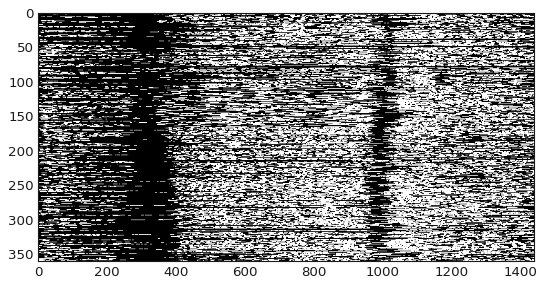

In [176]:
import matplotlib.style
import matplotlib as mpl
mpl.style.use('classic')

fig = plt.figure(figsize=(8, 4))
fig.patch.set_facecolor('white')

plt.imshow(np.vstack(daily_activity.values), cmap=plt.cm.gray, aspect=2);

## Joins

* Joins are common operations in databases.

* The idea is to combine several tables together, based on common values shared between the tables.

* In the current example, we have two DataFrames, `data` and `fare`, both with the same number of rows (one row per trip). 

* First, from the `fare` `DataFrame`, we will get the average tip obtained by each taxi. Then, we'll inject this information into the `data` `DataFrame`.

In [177]:
fare.head(3)

,medallion,hack_license,vendor_id,pickup_datetime,payment_type,fare_amount,surcharge,mta_tax,tip_amount,tolls_amount,total_amount
0,76942C3205E17D7E7FE5A9F709D16434,25BA06A87905667AA1FE5990E33F0E2E,VTS,2013-01-01 00:00:00,CSH,5.0,0.5,0.5,0.0,0.0,6.0
1,517C6B330DBB3F055D007B07512628B3,2C19FBEE1A6E05612EFE4C958C14BC7F,VTS,2013-01-01 00:05:00,CRD,13.5,0.5,0.5,2.8,0.0,17.3
2,ED15611F168E41B33619C83D900FE266,754AEBD7C80DA17BA1D81D89FB6F4D1D,CMT,2013-01-01 00:05:52,CSH,7.5,0.5,0.5,0.0,0.0,8.5


* To find the average tip per taxi, we will use `groupby()` again.

In [178]:
avg_tip = fare[['medallion', 'tip_amount']].loc[fare.tip_amount > 0].groupby('medallion').mean()
print(len(avg_tip))
avg_tip.head(3)

13407


,tip_amount
medallion,
00005007A9F30E289E760362F69E4EAD,1.815854
000318C2E3E6381580E5C99910A60668,2.857222
000351EDC735C079246435340A54C7C1,2.099111


* This is not exactly what we want; to combine the fares with the data we'll need to have `medallion` as a column, not as an index.

* To do that we'll use the `reset_index()` method so that although we group by `medallion` we get a numerical index.

* Otherwise `medallion` will become the index.

In [179]:
avg_tip = avg_tip.reset_index()
print(len(avg_tip))
avg_tip.head(3)

13407


,medallion,tip_amount
0,00005007A9F30E289E760362F69E4EAD,1.815854
1,000318C2E3E6381580E5C99910A60668,2.857222
2,000351EDC735C079246435340A54C7C1,2.099111


* Let's plot a histogram of the tips.

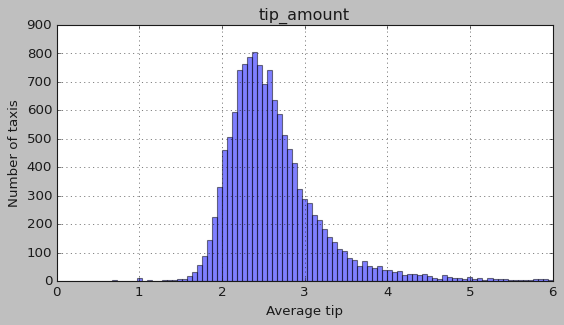

In [181]:
avg_tip.hist(bins=np.linspace(0.0, 6.0, 100), 
             color='blue', edgecolor='black', 
             alpha=0.5, figsize=(8, 4))
plt.xlabel('Average tip'); plt.ylabel('Number of taxis');

* We'll also get the average distance travelled per taxi.


In [182]:
avg_distance = data[['medallion', 'trip_distance']].loc[data.trip_distance > 0].groupby('medallion').mean().reset_index()
print(len(avg_distance))
avg_distance.head(3)

13427


,medallion,trip_distance
0,00005007A9F30E289E760362F69E4EAD,2.154118
1,000318C2E3E6381580E5C99910A60668,2.553636
2,000351EDC735C079246435340A54C7C1,2.257426


* To see how a (left) join works, see the following image.


![Left Join](left_join.png)

* The next step is to join `tip_amount` from `avg_tip` and the `trip_distance` from `avg_distance`. 

* The `medallion` column appears in both the `avg_tip` and the `avg_distance` DataFrames.

* By identifying this special  field (also called the key) in both data sets, we can associate every row in `avg_tip` to a row in `avg_distance`. This operation is called a join in SQL.

* We do this with the `merge()` method in pandas.

In [183]:
data_merged = pd.merge(avg_distance, avg_tip, how='left', on='medallion')
data_merged.head(3)

,medallion,trip_distance,tip_amount
0,00005007A9F30E289E760362F69E4EAD,2.154118,1.815854
1,000318C2E3E6381580E5C99910A60668,2.553636,2.857222
2,000351EDC735C079246435340A54C7C1,2.257426,2.099111


# Exercises
1. Load in Pandas the `balanced_corpus.csv` directly from [the respective repository](https://github.com/greek-proverb-atlas/proverbs.gr/tree/main/data).
2. Create a histogram of the two geographical coordinates provided (shown as subfigures of the same figure).
2. Find the collector with the most recorded proverbs. 
3. Group by the name of the collector you found in the previous step and visualise the most frequent places as a bar chart. 